## Загрузка датасета

В данном блокноте я буду проводить разведочный анализ на датасете "Sleep Health and Lifestyle", в котором преобладают числовые данные. Импорт библиотек:

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Загрузка датасета:

In [272]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Выведем информацию о столбцах:

In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


Проведём базовую оценку числовых признаков:

In [274]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


И категориальных:

In [275]:
df.describe(include='O')

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


## Чистка датасета

Для начала оценим количество дубликатов:

In [276]:
duplicate_rows = df[df.duplicated()]
print(f"В датасете всего {duplicate_rows.shape[0]} дубликатов")

В датасете всего 0 дубликатов


Избавимся от столбцов 'blood pressure' и 'heart rate':

In [277]:
df = df.drop(['Blood Pressure', 'Heart Rate'], axis=1)

По предыдущим выводам можно было заметить, что в столбце 'Sleep Disorder' у нас есть отсутствующие значения. Какие вообще варианты значений в данном столбце могут быть?

In [278]:
df['Sleep Disorder'].value_counts()

,count
Sleep Disorder,
Sleep Apnea,78
Insomnia,77


Поскольку среди значений нет явно выраженного "None", смею предположить, что NaN в данном случае - признак отсутствия расстройств сна, а не "дырявые данные". Можем использовать гистограмму, чтобы наглядно увидеть наличие/отсутствие у человека расстройства сна:

<Axes: xlabel='Sleep Disorder', ylabel='count'>

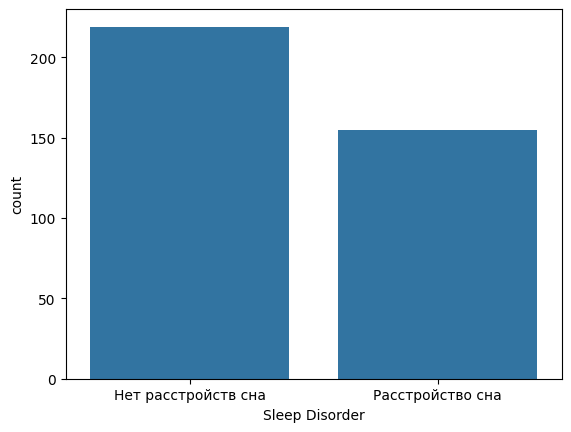

In [279]:
is_null = df['Sleep Disorder'].isnull().map({True: 'Нет расстройств сна', False: 'Расстройство сна'})

sns.countplot(x=is_null)

Заметно, что преобладают здоровые люди. Разобъем столбец по методу горячего кодирования:

In [280]:
disorders = pd.get_dummies(df['Sleep Disorder'], prefix='Sleep_Disorder', dtype=int)
df = pd.concat([df, disorders], axis=1).drop(['Sleep Disorder'], axis=1)
df.head(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Daily Steps,Sleep_Disorder_Insomnia,Sleep_Disorder_Sleep Apnea
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,4200,0,0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,10000,0,0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,10000,0,0
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,3000,0,1
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,3000,0,1


Рассмотрим признак "BMI Category". Оценим количество людей с определенной весовой категорией:

<Axes: xlabel='BMI Category', ylabel='count'>

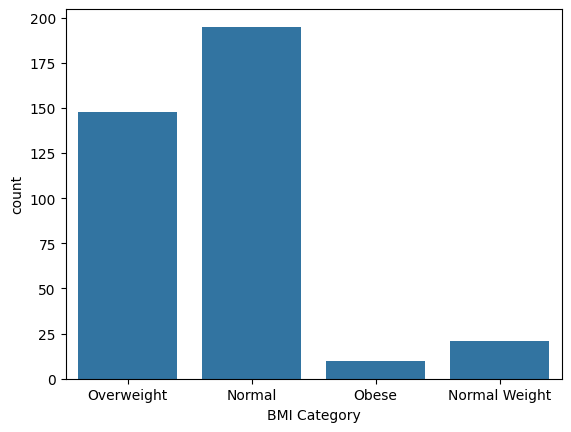

In [281]:
sns.countplot(x=df['BMI Category'])

Почему-то "Normal" и "Normal Weight" - разные весовые категории, объединим их. Также заметен явный дисбаланс в количестве людей с нормальным/избыточным весом и ожирением. Объединим "Overweight" и "Obese" в одну категорию "Above Normal":

<Axes: xlabel='BMI Category', ylabel='count'>

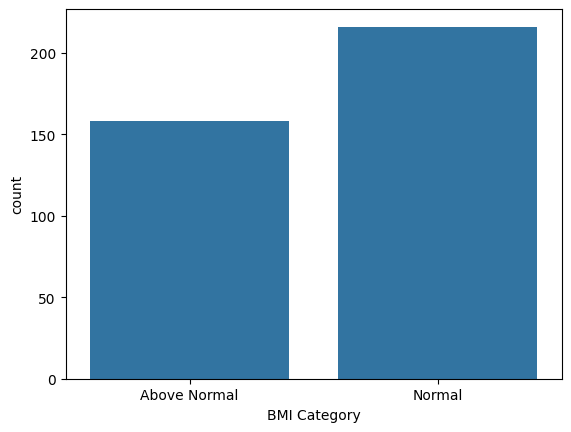

In [282]:
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
df['BMI Category'] = df['BMI Category'].replace(['Obese', 'Overweight'], 'Above Normal')
sns.countplot(x=df['BMI Category'])

Оставим один бинарный признак - ИМТ выше нормы:

In [283]:
bmi = pd.get_dummies(df['BMI Category'], prefix='bmi_category', dtype=int)
df = pd.concat([df, bmi], axis=1).drop(['BMI Category', 'bmi_category_Normal'], axis=1)
df.head(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Daily Steps,Sleep_Disorder_Insomnia,Sleep_Disorder_Sleep Apnea,bmi_category_Above Normal
0,1,Male,27,Software Engineer,6.1,6,42,6,4200,0,0,1
1,2,Male,28,Doctor,6.2,6,60,8,10000,0,0,0
2,3,Male,28,Doctor,6.2,6,60,8,10000,0,0,0
3,4,Male,28,Sales Representative,5.9,4,30,8,3000,0,1,1
4,5,Male,28,Sales Representative,5.9,4,30,8,3000,0,1,1


Распределение полов:

<Axes: xlabel='Gender', ylabel='count'>

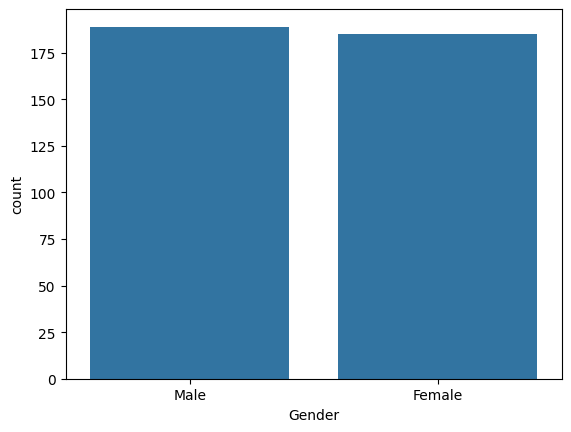

In [284]:
sns.countplot(x=df['Gender'])

Примерно одинаково количество людей обоих полов. Оценим распределение людей по профессиям:

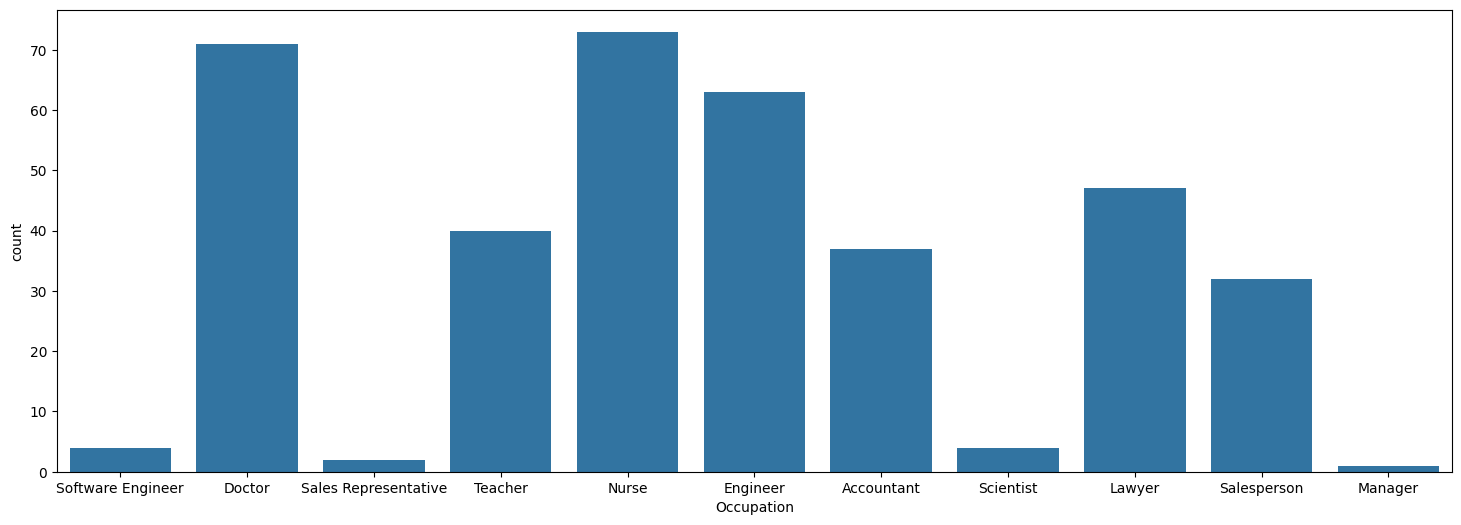

In [285]:
plt.figure(figsize=(18, 6))
sns.countplot(x=df['Occupation'])
plt.show()

In [286]:
df['Occupation'].value_counts()

,count
Occupation,
Nurse,73
Doctor,71
Engineer,63
Lawyer,47
Teacher,40
Accountant,37
Salesperson,32
Scientist,4
Software Engineer,4


И снова заметно, что значения, которые могли бы находиться в одной категории, оказались в разных. Объединим 'Salesperson' и "Sales Represantative' в 'Salesperson', 'Engineer Occupation" и "Software Engineer' в 'Engineer', удалим остальные строки, где значение < 10:

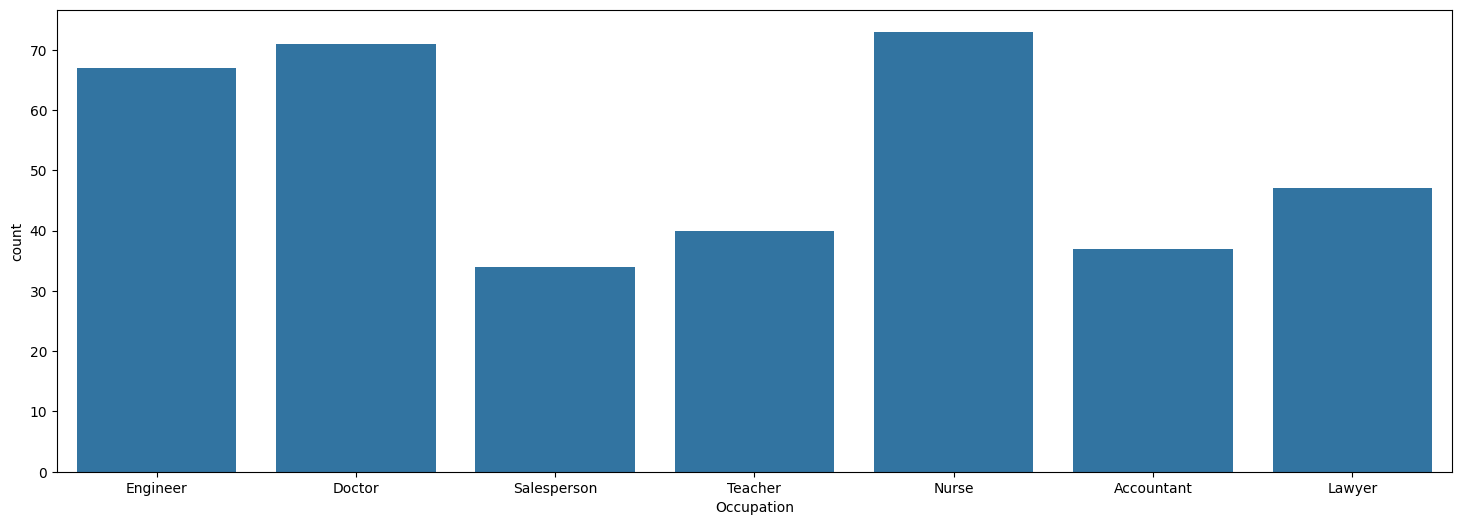

In [287]:
df['Occupation'] = df['Occupation'].replace(['Sales Representative'], 'Salesperson')
df['Occupation'] = df['Occupation'].replace(['Software Engineer', 'Engineer Occupation'], 'Engineer')

indices_to_drop = df[df['Occupation'].isin(['Scientist', 'Manager'])].index
df = df.drop(index=indices_to_drop)

plt.figure(figsize=(18, 6))
sns.countplot(x=df['Occupation'])
plt.show()

## Разведочный анализ
### Влияние профессии на сон

Оценим медиану (устойчива к выбросам) качества сна в зависимости от профессии:

In [288]:
print("Качество сна в зависимости от профессии:")
df.groupby('Occupation')['Quality of Sleep'].median()

Качество сна в зависимости от профессии:


,Quality of Sleep
Occupation,
Accountant,8.0
Doctor,7.0
Engineer,8.0
Lawyer,8.0
Nurse,6.0
Salesperson,6.0
Teacher,7.0


И медиану продолжительности сна:

In [289]:
print("Продолжительность сна в зависимости от профессии:")
df.groupby('Occupation')['Sleep Duration'].median()

Продолжительность сна в зависимости от профессии:


,Sleep Duration
Occupation,
Accountant,7.2
Doctor,7.6
Engineer,7.8
Lawyer,7.3
Nurse,6.5
Salesperson,6.4
Teacher,6.6


Построим графики качества и количества сна в зависимости от профессии. Для достоверности результата, будем учитывать на графике только професси, где > 10 представителей.

/tmp/ipykernel_7216/1107356512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Sleep Duration', y='Occupation', jitter=True, alpha=0.7, palette='Set1')


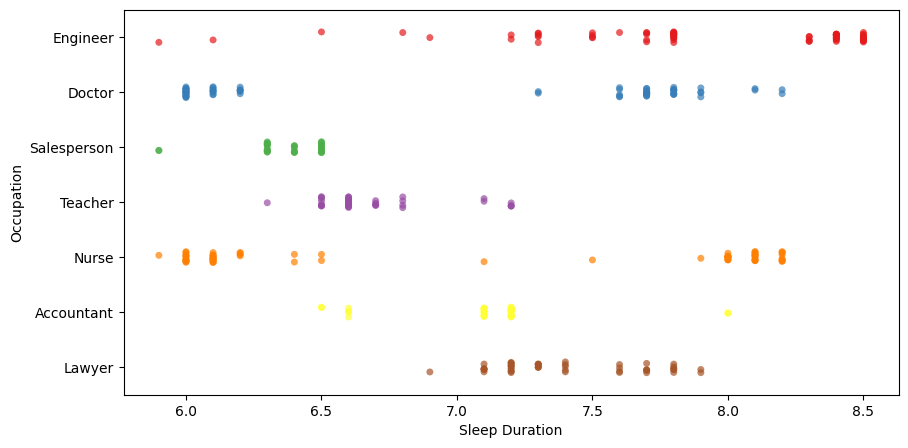

In [290]:
plt.figure(figsize=(10, 5))
sns.stripplot(data=df, x='Sleep Duration', y='Occupation', jitter=True, alpha=0.7, palette='Set1')
plt.show()

/tmp/ipykernel_7216/187431445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Quality of Sleep', y='Occupation', palette='Pastel2')


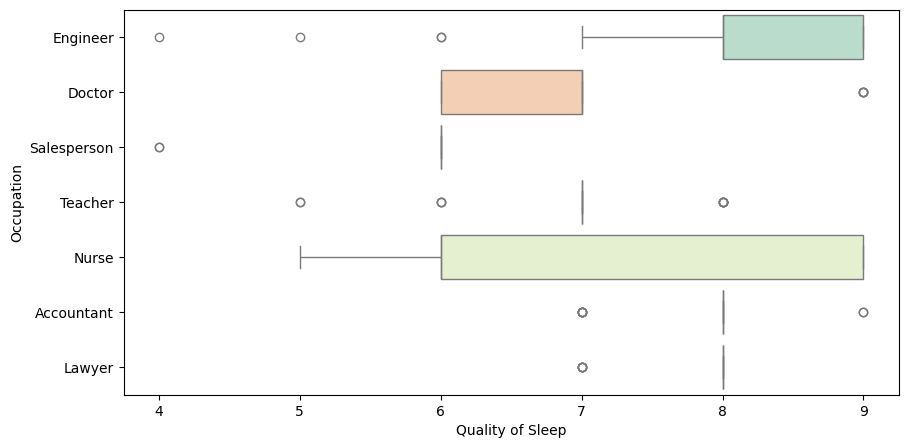

In [291]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Quality of Sleep', y='Occupation', palette='Pastel2')
plt.show()

Можем, заметить, что лучше всего спят инженеры (медианное качество сна - 8.0, продолжительность - 7.8), хуже всего - сфера продаж (качество - 6.0, продолжительность - 6.4) и медсёстры (качество - 6.0, продолжительность - 6.5)

### Влияние пола на сон

Проведём анализ, аналогичный анализу по профессии. Средние качества сна (не медианы, поскольку тут меньше шанс влияния выбросов из-за почти одинакового размера выборок):

In [292]:
print("Качество сна в зависимости от пола:")
df.groupby('Gender')['Quality of Sleep'].mean()

Качество сна в зависимости от пола:


,Quality of Sleep
Gender,
Female,7.727778
Male,6.968254


In [293]:
print("Продолжительность сна в зависимости от пола:")
df.groupby('Gender')['Sleep Duration'].mean()

Продолжительность сна в зависимости от пола:


,Sleep Duration
Gender,
Female,7.258889
Male,7.036508


Графики:

/tmp/ipykernel_7216/1160496165.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Gender', y='Quality of Sleep', palette='Set1')


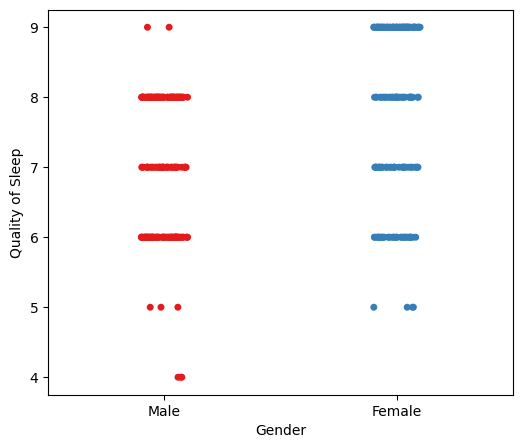

In [294]:
plt.figure(figsize=(6, 5))
sns.stripplot(data=df, x='Gender', y='Quality of Sleep', palette='Set1')
plt.show()

/tmp/ipykernel_7216/3976383600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Quality of Sleep', palette='Pastel2')


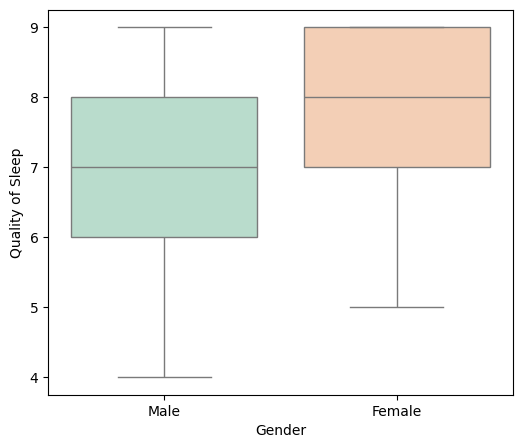

In [295]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Gender', y='Quality of Sleep', palette='Pastel2')
plt.show()

Можем увидеть, что женщины в целом спят лучше. У них выше среднее качество (7.73) и продолжительность (7.26) сна, чем у мужчин (6.97, 7.04)

## Корреляция числовых признаков и качества/продолжительности сна

Построим матрицу корреляции для числовых признаков

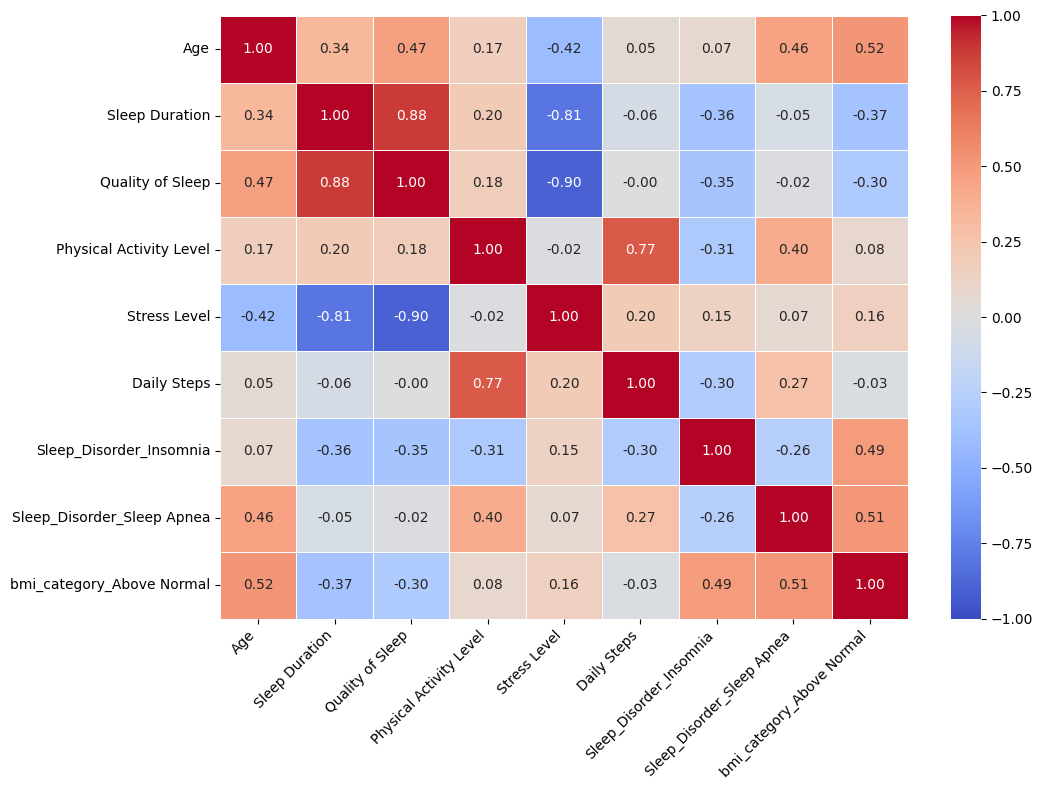

In [297]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(
    columns=['Person ID'], errors='ignore'
)

corr = numeric_df.corr()
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

По результатам матрицы корреляции можем выделить уровень стресса как наиболее значительный отрицально влияющий на качество сна фактор. Также наблюдается связь между избыточным весом и риском развития расстройств сна, возрастом и риском развиятия апноэ и появлением лишнего веса.   

Количество пройденных в день шагов и уровень физической активности коррелируют между собой. Возможно следовало на этапе чистки данных убрать один из этих факторов, в силу их взаимозаменяемости.

### Сравнение уровня стресса в разных профессиях/ для разных полов

Поскольку мы уже выяснили, что стресс наиболее значительно влияет на качество сна, а также знаем какие профессии/пол спят лучше всего, попробуем оценить уровень стресса по профессиям/полам

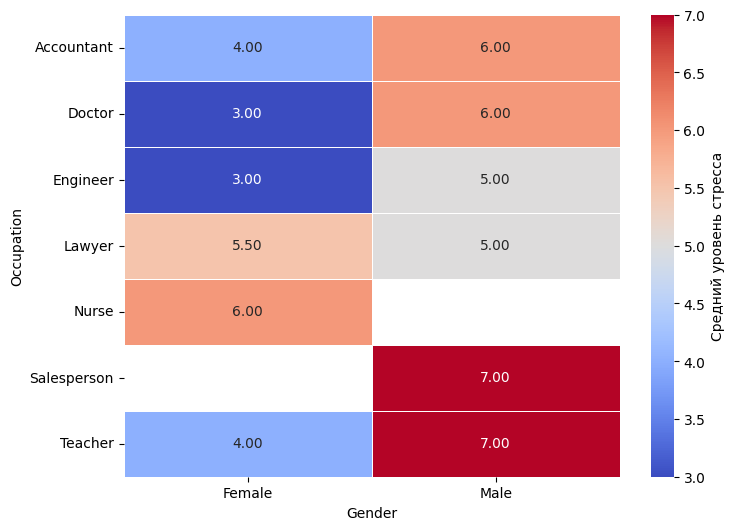

In [302]:
pivot_stress = df.pivot_table(
    index='Occupation',
    columns='Gender',
    values='Stress Level',
    aggfunc='median',
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_stress,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={'label': 'Средний уровень стресса'},
)

plt.show()

Как мы можем заметить: женщины, которые в среднем спят лучше, испытывают меньше стресса, чем мужчины. Меньше всего спят люди в сфере продаж - и у них самый высокий уровень стресса, за ними медсёстры - у них самый высокий уровень стресса среди "женских" профессий, больше всего спят инженеры - наименьший уровень стресса как среди женщин, так и мужчин. Учителей-мужчин со вторым среди всех худшим уровнем стресса уравновешивают женщины-учителя, и именно поэтому эта профессия в моём анализе не вошла в список хуже всех спящих.